In [1]:
import numpy as np
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Fundamental Constants

In [2]:
# Fundamental constants
h = constants.h  # Planck constant [J·s]
c = constants.c  # Speed of light [m/s]
e = constants.e  # Elementary charge [C]
m_e = constants.m_e  # Electron mass [kg]
epsilon_0 = constants.epsilon_0  # Vacuum permittivity [F/m]
mu_0 = constants.mu_0  # Vacuum permeability [H/m]
alpha = constants.fine_structure  # Fine structure constant (approximately 1/137)

# Space Time Potential Theory fundamental constant
eta = 1/(4*np.pi*1e-7)  # Vacuum viscosity [Pa·s]
rho = 2.41e-1  # Substrate density [kg/m³]

# Derived constants
hbar = h/(2*np.pi)  # Reduced Planck constant [J·s]
k = h/m_e  # Specific circulation for electron [m²/s]

## Calculate Vortex Parameters Using the Fine Structure Constant

In [3]:
# Calculate vortex parameters using the fine structure constant
# α = (1/4π²√3)·(r₀²/R²)
# Solving for r₀/R ratio:
r0_R_ratio = np.sqrt(alpha * 4 * np.pi**2 * np.sqrt(3))
print(f"Core radius to ring radius ratio (r₀/R): {r0_R_ratio:.8f}")

# Calculate ring radius R based on elementary charge
# Using e = ρ·Γ·π·R = ρ·(h/m_e)·π·R
R = e/(rho * k * np.pi)
print(f"Ring radius (R): {R:.3e} m")

# Calculate core radius r₀
r0 = R * r0_R_ratio
print(f"Core radius (r₀): {r0:.3e} m")

Core radius to ring radius ratio (r₀/R): 0.70638724
Ring radius (R): 2.909e-16 m
Core radius (r₀): 2.055e-16 m


## Calculate Vortex Energy Using Ring Vortex Formula

In [4]:
# Calculate vortex energy using ring vortex formula
# E = ρΓ²R[ln(8R/r₀) - k'], where k' ≈ 0.25
k_prime = 0.25
vortex_energy = rho * (k**2) * R * (np.log(8*R/r0) - k_prime)
print(f"Vortex energy: {vortex_energy:.3e} J")
print(f"Electron rest energy (m_e·c²): {m_e*c**2:.3e} J")

Vortex energy: 8.076e-23 J
Electron rest energy (m_e·c²): 8.187e-14 J


## Calculate Angular/Magnetic and Linear/Dielectric Components of Charge

In [5]:
# Calculate angular/magnetic and linear/dielectric components of charge
# Angular component relates to circulation: e_magnetic = ρ·Γ·π·R
e_magnetic = rho * k * np.pi * R

# Linear component relates to linear momentum along the vortex core
# Using the relationship e_linear = (m_e·c)/(4π³√3·R)
e_linear = (m_e * c)/(4 * np.pi**3 * np.sqrt(3) * R)

print(f"Angular/magnetic component of charge: {e_magnetic:.3e} C")
print(f"Linear/dielectric component of charge: {e_linear:.3e} C")
print(f"Elementary charge: {e:.3e} C")

Angular/magnetic component of charge: 1.602e-19 C
Linear/dielectric component of charge: 4.370e-09 C
Elementary charge: 1.602e-19 C


## Calculate Relativistic Correction to Magnetic Moment

In [6]:
# Calculate relativistic correction to magnetic moment
# a_e = 1 + (3/4)·β², where β = v/c ≈ sqrt(α)
beta = np.sqrt(alpha)
a_e_calc = 1 + (3/4) * beta**2
a_e_measured = 1.00115965218128  # Measured g-factor/2
print(f"Calculated anomalous magnetic moment: {a_e_calc:.10f}")
print(f"Measured anomalous magnetic moment: {a_e_measured:.10f}")
print(f"Difference: {abs(a_e_calc - a_e_measured):.10f}")

Calculated anomalous magnetic moment: 1.0054730144
Measured anomalous magnetic moment: 1.0011596522
Difference: 0.0043133622


## Visualization of the Rankine Ring Vortex

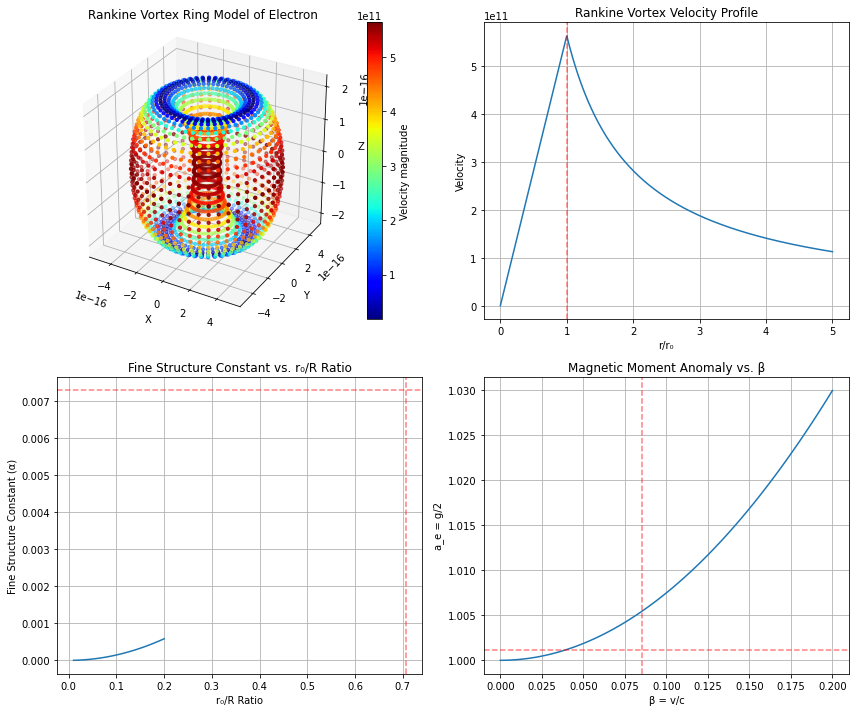

In [7]:
def rankine_velocity(r, r0, Gamma):
    """Calculate velocity for Rankine vortex model"""
    omega = Gamma/(2*np.pi*r0**2)  # Angular velocity inside core
    if r < r0:
        return omega * r  # Rigid body rotation
    else:
        return Gamma/(2*np.pi*r)  # Potential vortex

def generate_ring_vortex(R, r0, resolution=50):
    """Generate points for visualization of ring vortex with Rankine profile"""
    theta = np.linspace(0, 2*np.pi, resolution)
    phi = np.linspace(0, 2*np.pi, resolution)
    theta_grid, phi_grid = np.meshgrid(theta, phi)
    
    # Points on the torus
    x = (R + r0*np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r0*np.cos(phi_grid)) * np.sin(theta_grid)
    z = r0 * np.sin(phi_grid)
    
    # Calculate velocity field around the vortex ring
    Gamma = h/m_e  # Circulation
    
    # Simplified velocity field (not physically accurate, just for visualization)
    # In reality, the velocity field around a vortex ring is much more complex
    v_theta = np.zeros_like(x)
    for i in range(resolution):
        for j in range(resolution):
            # Distance from point to ring centerline
            r_dist = abs(np.sqrt(x[i,j]**2 + y[i,j]**2) - R)
            # Apply Rankine velocity profile
            v_theta[i,j] = rankine_velocity(r_dist, r0, Gamma)
    
    return x, y, z, v_theta

# Create visualization
fig = plt.figure(figsize=(12, 10))

# 3D plot of vortex ring
ax1 = fig.add_subplot(221, projection='3d')
x, y, z, v = generate_ring_vortex(R, r0)
sc = ax1.scatter(x, y, z, c=v, cmap='jet', s=10)
plt.colorbar(sc, ax=ax1, label='Velocity magnitude')
ax1.set_title('Rankine Vortex Ring Model of Electron')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_box_aspect([1,1,1])

# Plot of velocity profile
ax2 = fig.add_subplot(222)
r_values = np.linspace(0, r0*5, 1000)
v_values = [rankine_velocity(r, r0, k) for r in r_values]
ax2.plot(r_values/r0, v_values)
ax2.axvline(1.0, color='red', linestyle='--', alpha=0.5)
ax2.set_title('Rankine Vortex Velocity Profile')
ax2.set_xlabel('r/r₀')
ax2.set_ylabel('Velocity')
ax2.grid(True)

# Relationship between α and r₀/R ratio
ax3 = fig.add_subplot(223)
ratio_values = np.linspace(0.01, 0.2, 100)
alpha_values = (ratio_values**2)/(4*np.pi**2*np.sqrt(3))
ax3.plot(ratio_values, alpha_values)
ax3.axhline(alpha, color='red', linestyle='--', alpha=0.5)
ax3.axvline(r0_R_ratio, color='red', linestyle='--', alpha=0.5)
ax3.set_title('Fine Structure Constant vs. r₀/R Ratio')
ax3.set_xlabel('r₀/R Ratio')
ax3.set_ylabel('Fine Structure Constant (α)')
ax3.grid(True)

# Magnetic moment anomaly relationship
ax4 = fig.add_subplot(224)
beta_values = np.linspace(0, 0.2, 100)
a_e_values = 1 + (3/4) * beta_values**2
ax4.plot(beta_values, a_e_values)
ax4.axhline(a_e_measured, color='red', linestyle='--', alpha=0.5)
ax4.axvline(beta, color='red', linestyle='--', alpha=0.5)
ax4.set_title('Magnetic Moment Anomaly vs. β')
ax4.set_xlabel('β = v/c')
ax4.set_ylabel('a_e = g/2')
ax4.grid(True)

plt.tight_layout()
plt.savefig("electron_vortex_model.png", dpi=300)
plt.show()

## Additional Analysis: Fine Structure Constant from Hollow Core Ratio

In [8]:
def alpha_from_hollow_core_ratio(epsilon):
    """Calculate fine structure constant from hollow core ratio epsilon"""
    return epsilon**2/(8*np.pi**2*np.sqrt(3))

# Solve for epsilon value that gives correct fine structure constant
epsilon_target = np.sqrt(8*np.pi**2*np.sqrt(3)*alpha)
print(f"Hollow core ratio (ε) for correct α: {epsilon_target:.8f}")

# Calculate magnetic moment anomaly from this epsilon
a_e_from_epsilon = 1 + (3/4) * epsilon_target**2
print(f"Magnetic moment anomaly from ε: {a_e_from_epsilon:.10f}")

Hollow core ratio (ε) for correct α: 0.99898242
Magnetic moment anomaly from ε: 1.7484744033
